
#  BirdCLEF 2026 — Validation Notebook (Tasks 3, 4, 7)
#  models:
#    M1 — EfficientNetV2-S + SED attention   LB: 0.748
#    M2 — AST Transformer (from scratch)     LB: 0.544
#    M3 — ResNet34 + SED attention           LB: 0.721



In [1]:

import os
import gc
import json
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import torchaudio.transforms as T
import timm

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, average_precision_score
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"PyTorch    : {torch.__version__}")
print(f"torchaudio : {torchaudio.__version__}")
print(f"CUDA       : {torch.cuda.is_available()}")

PyTorch    : 2.10.0+cu128
torchaudio : 2.10.0+cu128
CUDA       : True


In [2]:
# ── CELL 2: Config ───────────────────────────────────────────

class CFG:
    # ── Датасет змагання ──
    BASE_DIR        = "/kaggle/input/competitions/birdclef-2026"
    TRAIN_AUDIO_DIR = f"{BASE_DIR}/train_audio"
    TRAIN_CSV       = f"{BASE_DIR}/train.csv"
    TAXONOMY_CSV    = f"{BASE_DIR}/taxonomy.csv"

    # EfficientNetV2-S 
    M1_DIR     = "/kaggle/input/datasets/studentedvard/birdclef-model-v1-zvuk2"
    M1_WEIGHTS = f"{M1_DIR}/bird_sed_model.pth"
    M1_META    = f"{M1_DIR}/target_columns.json"
    M1_NAME    = "efficientnetv2_s"
    M1_LB      = 0.748

    # AST Transformer 
    M2_DIR     = "/kaggle/input/datasets/studentedvard/zvuk2-ast-model"
    M2_WEIGHTS = f"{M2_DIR}/bird_ast_model.pth"
    M2_META    = f"{M2_DIR}/target_columns.json"
    M2_LB      = 0.544

    # ResNet34 + SED 
    M3_DIR     = "/kaggle/input/datasets/yaneshumliu/12-epoch-data"
    M3_WEIGHTS = f"{M3_DIR}/bird_sed_resnet34.pth"
    M3_META    = f"{M3_DIR}/target_columns.json"
    M3_NAME    = "resnet34"
    M3_LB      = 0.721  

    OUTPUT_DIR = "/kaggle/working"

    
    TARGET_SR   = 32_000
    SEGMENT_SEC = 5.0
    N_MELS      = 128
    N_FFT       = 1024
    HOP_LENGTH  = 320
    FMIN        = 20.0
    FMAX        = 16_000.0

    # Val split 
    N_FOLDS  = 5
    VAL_FOLD = 4

    BATCH_SIZE  = 32
    NUM_WORKERS = 2

    # AST 
    SPEC_TIME_FRAMES = 512
    PATCH_FREQ = 16
    PATCH_TIME = 16
    D_MODEL    = 384
    N_HEADS    = 6
    N_LAYERS   = 12
    MLP_RATIO  = 4.0

    MIN_POSITIVES = 5 

    DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    AMP_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


cfg = CFG()
Path(cfg.OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
print(f"Device : {cfg.DEVICE}")

Device : cuda


In [3]:
# Val split 

df       = pd.read_csv(cfg.TRAIN_CSV)
taxonomy = pd.read_csv(cfg.TAXONOMY_CSV)

TARGET_COLUMNS = sorted(taxonomy["primary_label"].astype(str).unique().tolist())
NUM_CLASSES    = len(TARGET_COLUMNS)
LABEL2IDX      = {lbl: i for i, lbl in enumerate(TARGET_COLUMNS)}

df["file_path"]     = cfg.TRAIN_AUDIO_DIR + "/" + df["filename"].astype(str)
df["primary_label"] = df["primary_label"].astype(str)

skf = StratifiedKFold(n_splits=cfg.N_FOLDS, shuffle=True, random_state=SEED)
df["fold"] = -1
for fold_idx, (_, val_idx) in enumerate(skf.split(df, df["primary_label"])):
    df.loc[df.index[val_idx], "fold"] = fold_idx

val_df = df[df["fold"] == cfg.VAL_FOLD].reset_index(drop=True)

print(f"Total samples  : {len(df):,}")
print(f"Val   samples  : {len(val_df):,}")
print(f"Unique species : {NUM_CLASSES}")

Total samples  : 35,549
Val   samples  : 7,109
Unique species : 234


In [4]:
class ValDataset(Dataset):
    def __init__(self, df, num_classes, label2idx, fixed_time=False):
        self.df          = df.reset_index(drop=True)
        self.num_classes = num_classes
        self.label2idx   = label2idx
        self.fixed_time  = fixed_time
        self.seg_len     = int(cfg.SEGMENT_SEC * cfg.TARGET_SR)

        self.mel = T.MelSpectrogram(
            sample_rate=cfg.TARGET_SR, n_fft=cfg.N_FFT,
            hop_length=cfg.HOP_LENGTH, n_mels=cfg.N_MELS,
            f_min=cfg.FMIN, f_max=cfg.FMAX,
        )
        self.db = T.AmplitudeToDB(stype="power", top_db=80)

    def __len__(self):
        return len(self.df)

    def _load(self, path):
        try:
            wav, _ = torchaudio.load(path)
        except Exception:
            return torch.zeros(1, self.seg_len)
        if wav.shape[0] > 1:
            wav = wav.mean(dim=0, keepdim=True)
        if wav.shape[1] >= self.seg_len:
            start = (wav.shape[1] - self.seg_len) // 2
            wav   = wav[:, start : start + self.seg_len]
        else:
            wav = F.pad(wav, (0, self.seg_len - wav.shape[1]))
        return wav

    def _spec(self, wav):
        spec = self.db(self.mel(wav))
        if self.fixed_time:
            T_fix = cfg.SPEC_TIME_FRAMES
            spec  = spec[:, :, :T_fix] if spec.shape[2] >= T_fix \
                    else F.pad(spec, (0, T_fix - spec.shape[2]))
        mean = spec.mean()
        std  = spec.std() + 1e-6
        return (spec - mean) / std

    def __getitem__(self, idx):
        row  = self.df.iloc[idx]
        spec = self._spec(self._load(row["file_path"]))
        lbl  = torch.zeros(self.num_classes, dtype=torch.float32)
        key  = str(row["primary_label"])
        if key in self.label2idx:
            lbl[self.label2idx[key]] = 1.0
        return spec, lbl

Architecture definitions for CNN-SED (M1, M3) and AST (M2)

In [5]:
import torch
import torch.nn as nn
import timm


class BirdSEDModel(nn.Module):
    """CNN + SED-attention голова. Підтримує будь-який timm backbone."""

    def __init__(self, model_name: str, num_classes: int):
        super().__init__()
        self.backbone = timm.create_model(
            model_name, pretrained=False,
            in_chans=1, num_classes=0, global_pool="",
        )
        with torch.no_grad():
            dummy = torch.zeros(1, 1, 128, 312)
            feat  = self.backbone(dummy)
            in_ch = feat.shape[1]

        self.dropout = nn.Dropout(0.3)
        self.fc_clip = nn.Linear(in_ch, num_classes)
        self.fc_att  = nn.Linear(in_ch, num_classes)

    def forward(self, x):
        feat = self.backbone(x)
        feat = feat.mean(dim=2).permute(0, 2, 1)
        feat = self.dropout(feat)
        clip = self.fc_clip(feat)
        att  = torch.softmax(self.fc_att(feat), dim=1)
        return (torch.sigmoid(clip) * att).sum(dim=1)


class PatchEmbed(nn.Module):
    def __init__(self, freq_bins, time_frames, patch_freq, patch_time, d_model):
        super().__init__()
        self.n_patch = (freq_bins // patch_freq) * (time_frames // patch_time)
        self.proj    = nn.Conv2d(
            1, d_model,
            kernel_size=(patch_freq, patch_time),
            stride     =(patch_freq, patch_time),
        )
    def forward(self, x):
        return self.proj(x).flatten(2).transpose(1, 2)


class TransformerBlock(nn.Module):
    def __init__(self, d_model, n_heads, mlp_ratio, dropout):
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.attn  = nn.MultiheadAttention(
            d_model, n_heads, dropout=dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(d_model)
        dim        = int(d_model * mlp_ratio)
        self.mlp   = nn.Sequential(
            nn.Linear(d_model, dim), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(dim, d_model), nn.Dropout(dropout),
        )
    def forward(self, x):
        h, _ = self.attn(self.norm1(x), self.norm1(x), self.norm1(x),
                         need_weights=False)
        x = x + h
        return x + self.mlp(self.norm2(x))


class AudioSpectrogramTransformer(nn.Module):
    def __init__(self, num_classes, freq_bins, time_frames,
                 patch_freq, patch_time, d_model, n_heads,
                 n_layers, mlp_ratio, dropout=0.0):
        super().__init__()
        self.patch_embed = PatchEmbed(
            freq_bins, time_frames, patch_freq, patch_time, d_model)
        n_patch        = self.patch_embed.n_patch
        self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))
        self.pos_embed = nn.Parameter(torch.zeros(1, n_patch + 1, d_model))
        self.pos_drop  = nn.Dropout(dropout)
        self.blocks    = nn.Sequential(*[
            TransformerBlock(d_model, n_heads, mlp_ratio, dropout)
            for _ in range(n_layers)
        ])
        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Sequential(
            nn.Linear(d_model, d_model // 2), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(d_model // 2, num_classes),
        )
    def forward(self, x):
        B = x.size(0)
        x = self.patch_embed(x)
        x = torch.cat([self.cls_token.expand(B, -1, -1), x], dim=1)
        x = self.pos_drop(x + self.pos_embed)
        x = self.norm(self.blocks(x))
        return torch.sigmoid(self.head(x[:, 0]))

In [6]:
with open(cfg.M3_META) as _f:
    M3_TARGET_COLUMNS = json.load(_f)
M3_NUM_CLASSES = len(M3_TARGET_COLUMNS)
print(f"M3 has {M3_NUM_CLASSES} classes (taxonomy has {NUM_CLASSES})")

M3_REMAP = {}
_m3_set = {c: i for i, c in enumerate(M3_TARGET_COLUMNS)}
for target_idx, col in enumerate(TARGET_COLUMNS):
    if col in _m3_set:
        M3_REMAP[target_idx] = _m3_set[col]
print(f"Classes shared between M3 and taxonomy: {len(M3_REMAP)} / {NUM_CLASSES}")


def load_sed_model(model_name, weights_path, num_classes, device):
    model = BirdSEDModel(model_name, num_classes).to(device)
    sd    = torch.load(weights_path, map_location=device, weights_only=True)
    model.load_state_dict(sd, strict=False)
    model.eval()
    n = sum(p.numel() for p in model.parameters())
    print(f"  OK {model_name:25s} | params: {n:,} | {Path(weights_path).name}")
    return model


def load_ast_model(weights_path, num_classes, device, cfg):
    ckpt  = torch.load(weights_path, map_location=device)
    snap  = ckpt.get("cfg_snapshot", {})
    model = AudioSpectrogramTransformer(
        num_classes = num_classes,
        freq_bins   = snap.get("N_MELS",            cfg.N_MELS),
        time_frames = snap.get("SPEC_TIME_FRAMES",  cfg.SPEC_TIME_FRAMES),
        patch_freq  = snap.get("PATCH_FREQ",        cfg.PATCH_FREQ),
        patch_time  = snap.get("PATCH_TIME",        cfg.PATCH_TIME),
        d_model     = snap.get("D_MODEL",           cfg.D_MODEL),
        n_heads     = snap.get("N_HEADS",           cfg.N_HEADS),
        n_layers    = snap.get("N_LAYERS",          cfg.N_LAYERS),
        mlp_ratio   = snap.get("MLP_RATIO",         cfg.MLP_RATIO),
        dropout     = 0.0,
    ).to(device)
    model.load_state_dict(ckpt["model_state"])
    model.eval()
    n = sum(p.numel() for p in model.parameters())
    print(f"  OK AST Transformer             | params: {n:,} | {Path(weights_path).name}")
    return model


print("── Loading models ──")
model1 = load_sed_model(cfg.M1_NAME, cfg.M1_WEIGHTS, NUM_CLASSES,    cfg.DEVICE)
model2 = load_ast_model(cfg.M2_WEIGHTS,               NUM_CLASSES,    cfg.DEVICE, cfg)
model3 = load_sed_model(cfg.M3_NAME, cfg.M3_WEIGHTS, M3_NUM_CLASSES, cfg.DEVICE)
print("All models loaded.")

M3 has 234 classes (taxonomy has 234)
Classes shared between M3 and taxonomy: 234 / 234
── Loading models ──
  OK efficientnetv2_s          | params: 20,776,564 | bird_sed_model.pth
  OK AST Transformer             | params: 21,611,178 | bird_ast_model.pth
  OK resnet34                  | params: 21,518,484 | bird_sed_resnet34.pth
All models loaded.


In [7]:
#  DataLoaders 

loader_kwargs = dict(
    batch_size  = cfg.BATCH_SIZE,
    shuffle     = False,
    num_workers = cfg.NUM_WORKERS,
    pin_memory  = torch.cuda.is_available(),
)

# M1, M3 — standard CNNs
val_loader_cnn = DataLoader(
    ValDataset(val_df, NUM_CLASSES, LABEL2IDX, fixed_time=False),
    **loader_kwargs,
)

# M2 — AST requires a fixed time axis (T-axis)
val_loader_ast = DataLoader(
    ValDataset(val_df, NUM_CLASSES, LABEL2IDX, fixed_time=True),
    **loader_kwargs,
)

print(f"CNN val batches : {len(val_loader_cnn)}")
print(f"AST val batches : {len(val_loader_ast)}")

CNN val batches : 223
AST val batches : 223


In [8]:
# Inference 

def collect_predictions(model, loader, device, amp_device, desc="Predicting"):
    """Standard inference — model already outputs NUM_CLASSES outputs."""
    model.eval()
    all_probs  = []
    all_labels = []
    with torch.no_grad():
        for specs, labels in tqdm(loader, desc=f"  {desc}"):
            specs = specs.to(device)
            with torch.amp.autocast(device_type=amp_device):
                out = model(specs)
            if out.min() < 0 or out.max() > 1:
                out = torch.sigmoid(out)
            all_probs.append(out.cpu().float().numpy())
            all_labels.append(labels.cpu().numpy())
    return np.vstack(all_probs), np.vstack(all_labels)


def collect_predictions_remapped(model, loader, device, amp_device,
                                  remap, n_target_classes, desc="Predicting"):
    """
    Inference for M3: model outputs M3_NUM_CLASSES outputs, 
    we map them into the full n_target_classes (234) space.
    Classes not present in M3 are assigned 0.0.
    """
    model.eval()
    all_probs  = []
    all_labels = []
    with torch.no_grad():
        for specs, labels in tqdm(loader, desc=f"  {desc}"):
            specs = specs.to(device)
            with torch.amp.autocast(device_type=amp_device):
                out = model(specs)                         # (B, M3_NUM_CLASSES)
            if out.min() < 0 or out.max() > 1:
                out = torch.sigmoid(out)
            out_np = out.cpu().float().numpy()             # (B, M3_NUM_CLASSES)
            B = out_np.shape[0]
            remapped = np.zeros((B, n_target_classes), dtype=np.float32)
            for target_idx, m3_idx in remap.items():
                remapped[:, target_idx] = out_np[:, m3_idx]
            all_probs.append(remapped)
            all_labels.append(labels.cpu().numpy())
    return np.vstack(all_probs), np.vstack(all_labels)


print("── Collecting predictions ──")
y_score1, y_true = collect_predictions(
    model1, val_loader_cnn, cfg.DEVICE, cfg.AMP_DEVICE, "M1 EfficientNetV2-S")
gc.collect()

y_score2, _ = collect_predictions(
    model2, val_loader_ast, cfg.DEVICE, cfg.AMP_DEVICE, "M2 AST Transformer")
gc.collect()

# M3: using remapped inference — transferring M3_NUM_CLASSES -> 234
y_score3, _ = collect_predictions_remapped(
    model3, val_loader_cnn, cfg.DEVICE, cfg.AMP_DEVICE,
    M3_REMAP, NUM_CLASSES, "M3 ResNet34 (remapped)")
gc.collect()

print(f"\nVal samples   : {y_true.shape[0]}")
print(f"Num classes   : {y_true.shape[1]}")
print(f"M1 range: [{y_score1.min():.3f}, {y_score1.max():.3f}]")
print(f"M2 range: [{y_score2.min():.3f}, {y_score2.max():.3f}]")
print(f"M3 range: [{y_score3.min():.3f}, {y_score3.max():.3f}]")
print(f"M3 non-zero cols: {(y_score3 > 0).any(axis=0).sum()} / {NUM_CLASSES}")

── Collecting predictions ──


  M1 EfficientNetV2-S:   0%|          | 0/223 [00:00<?, ?it/s]

  M2 AST Transformer:   0%|          | 0/223 [00:00<?, ?it/s]

  M3 ResNet34 (remapped):   0%|          | 0/223 [00:00<?, ?it/s]


Val samples   : 7109
Num classes   : 234
M1 range: [0.000, 0.993]
M2 range: [0.001, 0.340]
M3 range: [0.000, 0.968]
M3 non-zero cols: 234 / 234


In [9]:

def compute_metrics(y_score, y_true, target_cols, min_pos=5):
    n     = y_true.shape[1]
    valid = [i for i in range(n) if y_true[:, i].sum() >= min_pos]
    print(f"  Valid classes (>= {min_pos} pos): {len(valid)} / {n}")

    aucs      = []
    per_class = {}
    for i in valid:
        try:
            a = roc_auc_score(y_true[:, i], y_score[:, i])
            aucs.append(a)
            per_class[target_cols[i]] = a
        except Exception:
            pass

    # padcROC calculation (mean of individual class AUCs)
    padcroc = float(np.mean(aucs)) if aucs else None

    try:
        macro_auc = roc_auc_score(
            y_true[:, valid], y_score[:, valid], average="macro")
    except Exception:
        macro_auc = None

    try:
        map_score = average_precision_score(
            y_true[:, valid], y_score[:, valid], average="macro")
    except Exception:
        map_score = None

    return {
        "padcROC_AUC":   padcroc,
        "Macro_ROC_AUC": macro_auc,
        "mAP":           map_score,
        "per_class_auc": per_class,
        "n_valid_cls":   len(valid),
    }


print("\nM1: EfficientNetV2-S")
m1 = compute_metrics(y_score1, y_true, TARGET_COLUMNS)

print("\nM2: AST Transformer")
m2 = compute_metrics(y_score2, y_true, TARGET_COLUMNS)

print("\nM3: ResNet34")
m3 = compute_metrics(y_score3, y_true, TARGET_COLUMNS)


M1: EfficientNetV2-S
  Valid classes (>= 5 pos): 169 / 234

M2: AST Transformer
  Valid classes (>= 5 pos): 169 / 234

M3: ResNet34
  Valid classes (>= 5 pos): 169 / 234


In [10]:
# ── CELL 10: Зведена таблиця ────────────────────────────────

def fmt(v):
    return round(v, 4) if v is not None else None

summary = pd.DataFrame([
    {
        "Model":        "EfficientNetV2-S (SED)",
        "Backbone":     "EfficientNetV2-S",
        "Epochs":       12,
        "Val padcROC":  fmt(m1["padcROC_AUC"]),
        "Val MacroAUC": fmt(m1["Macro_ROC_AUC"]),
        "Val mAP":      fmt(m1["mAP"]),
        "LB Score":     cfg.M1_LB,
    },
    {
        "Model":        "AST Transformer",
        "Backbone":     "Custom ViT",
        "Epochs":       15,
        "Val padcROC":  fmt(m2["padcROC_AUC"]),
        "Val MacroAUC": fmt(m2["Macro_ROC_AUC"]),
        "Val mAP":      fmt(m2["mAP"]),
        "LB Score":     cfg.M2_LB,
    },
    {
        "Model":        "ResNet34 (SED)",
        "Backbone":     "ResNet34",
        "Epochs":       12,
        "Val padcROC":  fmt(m3["padcROC_AUC"]),
        "Val MacroAUC": fmt(m3["Macro_ROC_AUC"]),
        "Val mAP":      fmt(m3["mAP"]),
        "LB Score":     cfg.M3_LB,
    },
])

print("\n" + "="*80)
print("  VALIDATION + LEADERBOARD SUMMARY")
print("="*80)
pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 120)
print(summary.to_string(index=False))

summary.to_csv(f"{cfg.OUTPUT_DIR}/metrics_summary.csv", index=False)
print(f"\nSaved -> {cfg.OUTPUT_DIR}/metrics_summary.csv")


  VALIDATION + LEADERBOARD SUMMARY
                 Model         Backbone  Epochs  Val padcROC  Val MacroAUC  Val mAP  LB Score
EfficientNetV2-S (SED) EfficientNetV2-S      12       0.9701        0.9701   0.6811     0.748
       AST Transformer       Custom ViT      15       0.6938        0.6938   0.0195     0.544
        ResNet34 (SED)         ResNet34      12       0.9593        0.9593   0.5856     0.721

Saved -> /kaggle/working/metrics_summary.csv



EfficientNetV2-S
  Top-8 best performing:
    dwatin1                                  1.0000
    whlspi1                                  0.9999
    lesgrf1                                  0.9998
    spispi1                                  0.9992
    24279                                    0.9989
    magant1                                  0.9989
    scadov1                                  0.9988
    bkhpar                                   0.9986
  Top-8 worst performing:
    23158                                    0.8753
    pluibi1                                  0.8927
    sobcac1                                  0.9135
    ruther1                                  0.9256
    greant1                                  0.9317
    tattin1                                  0.9324
    magtan2                                  0.9325
    linwoo1                                  0.9351

AST Transformer
  Top-8 best performing:
    purjay1                                  0.9023
    r

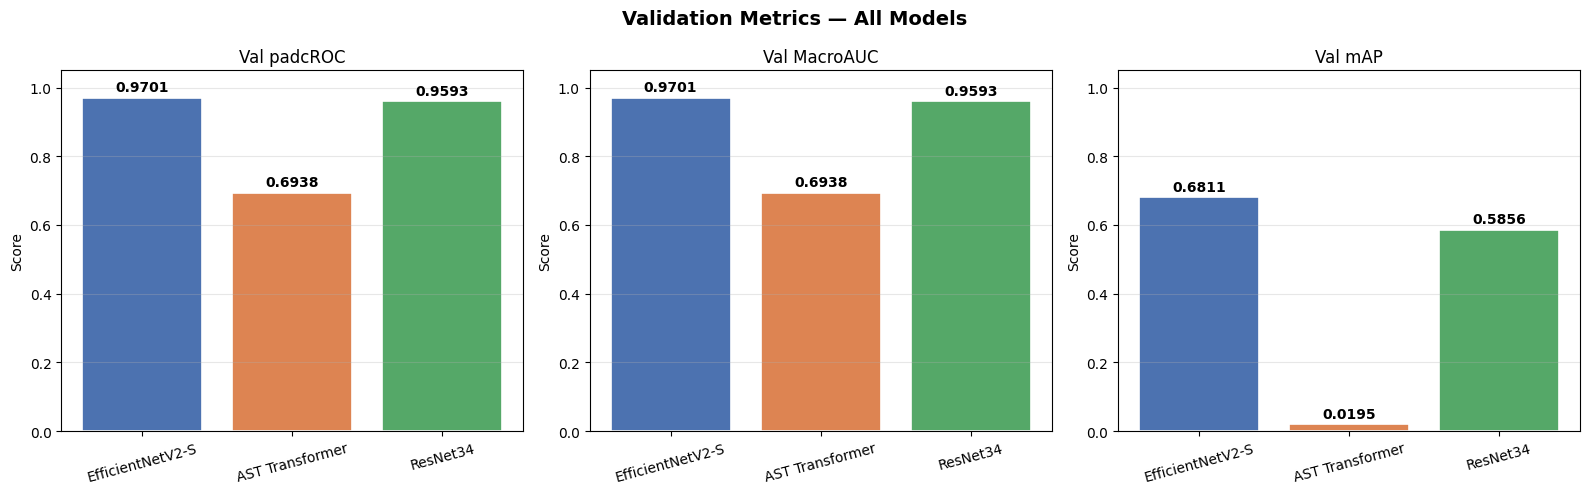

In [11]:
def print_per_class(per_cls, name, n=8):
    s = sorted(per_cls.items(), key=lambda x: x[1])
    print(f"\n{name}")
    print(f"  Top-{n} best performing:")
    for sp, auc in s[-n:][::-1]:
        print(f"    {sp:40s} {auc:.4f}")
    print(f"  Top-{n} worst performing:")
    for sp, auc in s[:n]:
        print(f"    {sp:40s} {auc:.4f}")

print_per_class(m1["per_class_auc"], "EfficientNetV2-S")
print_per_class(m2["per_class_auc"], "AST Transformer")
print_per_class(m3["per_class_auc"], "ResNet34")


MODEL_NAMES = ["EfficientNetV2-S", "AST Transformer", "ResNet34"]
COLORS      = ["#4C72B0", "#DD8452", "#55A868"]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Validation Metrics — All Models", fontsize=14, fontweight="bold")

for ax, col in zip(axes, ["Val padcROC", "Val MacroAUC", "Val mAP"]):
    vals = [summary.loc[i, col] for i in range(3)]
    bars = ax.bar(MODEL_NAMES, vals, color=COLORS, edgecolor="white", linewidth=1.2)
    ax.set_title(col, fontsize=12)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Score")
    ax.grid(axis="y", alpha=0.3)
    ax.tick_params(axis="x", rotation=15)
    for bar, v in zip(bars, vals):
        if v is not None:
            ax.text(bar.get_x() + bar.get_width() / 2, v + 0.01,
                    f"{v:.4f}", ha="center", va="bottom",
                    fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig(f"{cfg.OUTPUT_DIR}/val_metrics_comparison.png", dpi=150)
plt.show()

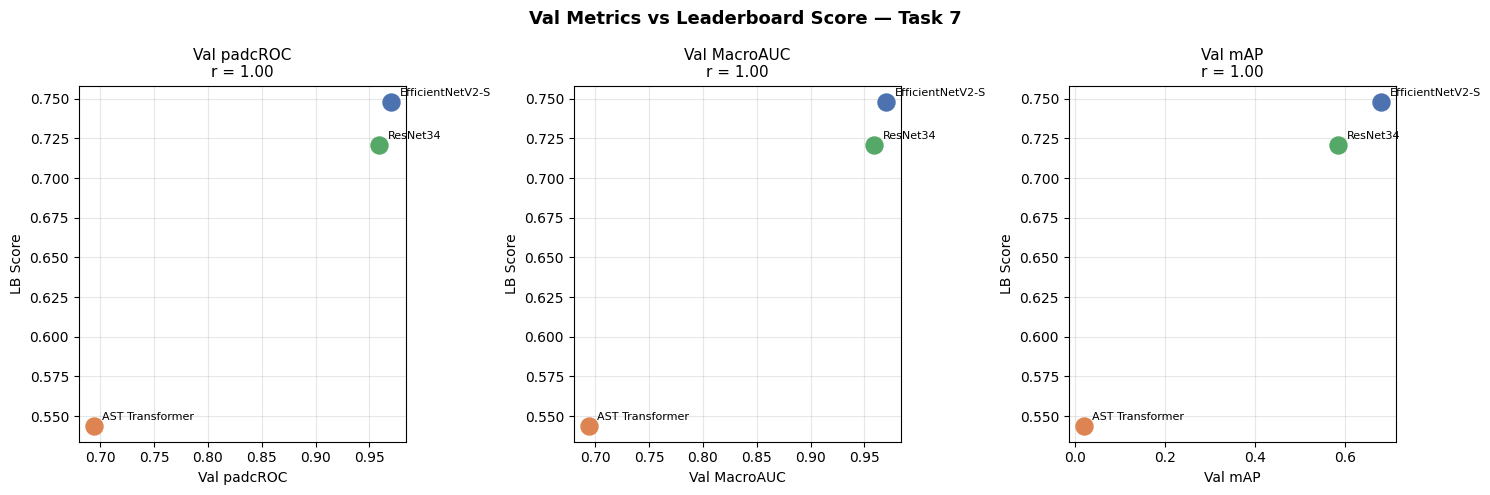

After M3 submission -> update cfg.M3_LB and rerun this cell.


In [12]:
# After submitting M3:
#   1. Fill cfg.M3_LB = <obtained score>
#   2. Rerun only this cell

lb_vals  = np.array([summary.loc[i, "LB Score"] for i in range(3)], dtype=object)
padcroc  = np.array([summary.loc[i, "Val padcROC"]  for i in range(3)], dtype=object)
macro    = np.array([summary.loc[i, "Val MacroAUC"] for i in range(3)], dtype=object)
map_vals = np.array([summary.loc[i, "Val mAP"]      for i in range(3)], dtype=object)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Val Metrics vs Leaderboard Score — Task 7", fontsize=13, fontweight="bold")

for ax, val_arr, col_name in zip(
    axes,
    [padcroc, macro, map_vals],
    ["Val padcROC", "Val MacroAUC", "Val mAP"],
):
    mask = [lb_vals[i] is not None and val_arr[i] is not None for i in range(3)]
    x = np.array(val_arr[mask], dtype=float)
    y = np.array(lb_vals[mask], dtype=float)
    c = np.array(COLORS)[mask]
    n = np.array(MODEL_NAMES)[mask]

    for xi, yi, ci, ni in zip(x, y, c, n):
        ax.scatter(xi, yi, color=ci, s=150, zorder=5)
        ax.annotate(ni, (xi, yi), textcoords="offset points",
                    xytext=(6, 4), fontsize=8)

    if len(x) >= 2:
        corr = np.corrcoef(x, y)[0, 1]
        ax.set_title(f"{col_name}\nr = {corr:.2f}", fontsize=11)
    else:
        ax.set_title(f"{col_name}\n(need >= 2 LB points)", fontsize=10)

    ax.set_xlabel(col_name)
    ax.set_ylabel("LB Score")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{cfg.OUTPUT_DIR}/correlation_val_vs_lb.png", dpi=150)
plt.show()
print("After M3 submission -> update cfg.M3_LB and rerun this cell.")

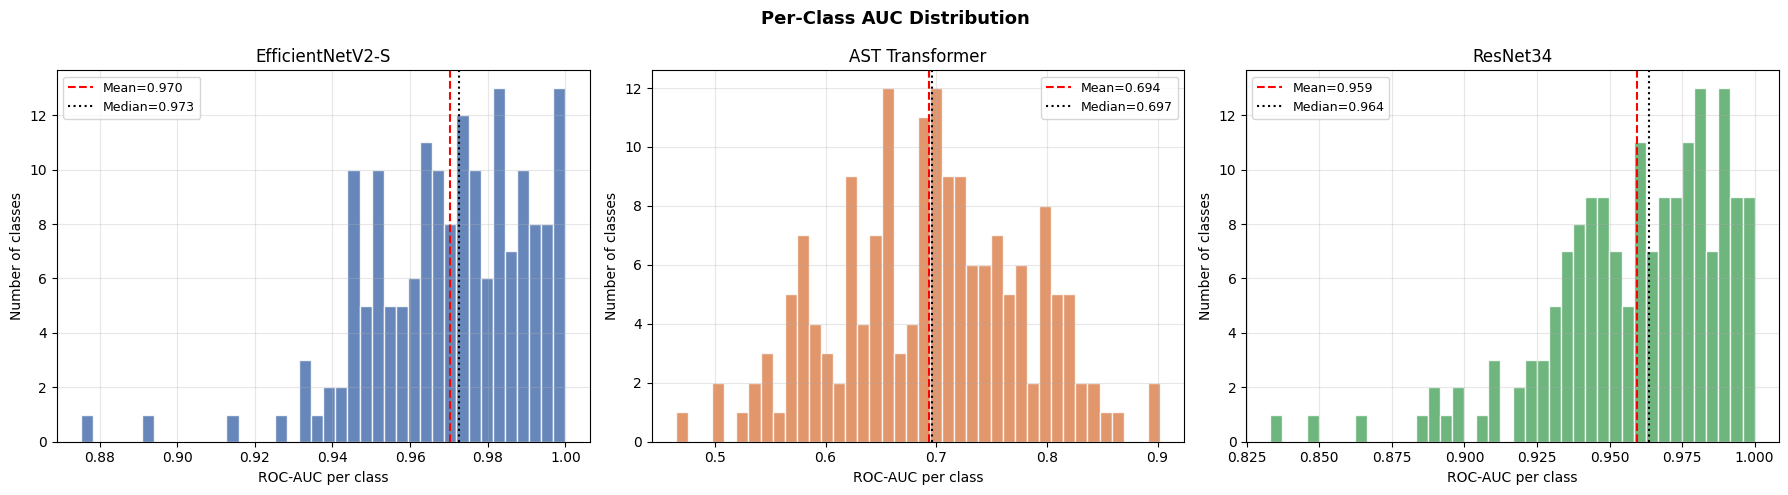

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Per-Class AUC Distribution", fontsize=13, fontweight="bold")

for ax, per_cls, name, color in zip(
    axes,
    [m1["per_class_auc"], m2["per_class_auc"], m3["per_class_auc"]],
    MODEL_NAMES, COLORS,
):
    vals = list(per_cls.values())
    ax.hist(vals, bins=40, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(np.mean(vals),   color="red",   linestyle="--",
               label=f"Mean={np.mean(vals):.3f}")
    ax.axvline(np.median(vals), color="black", linestyle=":",
               label=f"Median={np.median(vals):.3f}")
    ax.set_title(name)
    ax.set_xlabel("ROC-AUC per class")
    ax.set_ylabel("Number of classes")
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f"{cfg.OUTPUT_DIR}/per_class_auc_distribution.png", dpi=150)
plt.show()

In [14]:
print("""
METRIC ANALYSIS — TASK 4

Official BirdCLEF 2026 Metric: padcROC AUC
• Calculated only for classes with sufficient positive samples
  in test soundscapes - rare or absent species in the test set
  are completely ignored.
• Site-aware: it is crucial to correctly rank species that are
  actually present in a specific recording location.
• This is a partial AUC — the metric does not penalize errors
  on classes without test annotations.

Why val-metrics and LB might diverge:
  1. Class distribution in validation set != distribution in test soundscapes
  2. LB is calculated on real soundscapes, while validation is at the clip-level
  3. Soundscape inference (sliding window) != clip classification
""")

metric_table = pd.DataFrame([
    {
        "Metric":      "padcROC AUC",
        "Calculated":  "LB + Val (proxy)",
        "Advantage":   "Directly aligns with competition goals",
        "Disadvantage": "Hard to replicate exactly on validation set",
    },
    {
        "Metric":      "Macro ROC-AUC",
        "Calculated":  "Val",
        "Advantage":   "Simple and highly interpretable",
        "Disadvantage": "Gives equal weight regardless of frequency",
    },
    {
        "Metric":      "mAP",
        "Calculated":  "Val",
        "Advantage":   "Sensitive to precision, good for rare classes",
        "Disadvantage": "Can be optimistic with extreme imbalance",
    },
    {
        "Metric":      "Focal Loss",
        "Calculated":  "Train + Val",
        "Advantage":   "Focuses on hard examples",
        "Disadvantage": "Does not directly correlate with LB score",
    },
])
pd.set_option("display.max_colwidth", 55)
print(metric_table.to_string(index=False))


METRIC ANALYSIS — TASK 4

Official BirdCLEF 2026 Metric: padcROC AUC
• Calculated only for classes with sufficient positive samples
  in test soundscapes - rare or absent species in the test set
  are completely ignored.
• Site-aware: it is crucial to correctly rank species that are
  actually present in a specific recording location.
• This is a partial AUC — the metric does not penalize errors
  on classes without test annotations.

Why val-metrics and LB might diverge:
  1. Class distribution in validation set != distribution in test soundscapes
  2. LB is calculated on real soundscapes, while validation is at the clip-level
  3. Soundscape inference (sliding window) != clip classification

       Metric       Calculated                                     Advantage                                Disadvantage
  padcROC AUC LB + Val (proxy)        Directly aligns with competition goals Hard to replicate exactly on validation set
Macro ROC-AUC              Val               Simple an

In [15]:
print("\n" + "="*70)
print("  FINAL SUMMARY")
print("="*70)
print(summary[["Model", "Val padcROC", "Val MacroAUC",
                "Val mAP", "LB Score"]].to_string(index=False))

print(f"\nArtifacts -> {cfg.OUTPUT_DIR}/")
for f in ["metrics_summary.csv", "val_metrics_comparison.png",
          "per_class_auc_distribution.png", "correlation_val_vs_lb.png"]:
    print(f"  {f}")


  FINAL SUMMARY
                 Model  Val padcROC  Val MacroAUC  Val mAP  LB Score
EfficientNetV2-S (SED)       0.9701        0.9701   0.6811     0.748
       AST Transformer       0.6938        0.6938   0.0195     0.544
        ResNet34 (SED)       0.9593        0.9593   0.5856     0.721

Artifacts -> /kaggle/working/
  metrics_summary.csv
  val_metrics_comparison.png
  per_class_auc_distribution.png
  correlation_val_vs_lb.png
